# EEG Quickstart for Students

This notebook explains how to use the helper functions in `utils.py`.

You will learn how to:
- structure your project files,
- load data,
- select channels/trials/frequency bands,
- and visualize trials quickly.


## 0) Environment configuration and packages

**If you are on the ICE cluster:** you can skip this whole section. The environment and required packages are already configured there; just open this notebook and run the cells from section 1 onward.

**If you are running locally** (your own laptop or PC), follow the steps below to avoid common setup issues.

### Environment configuration (recommended)

Use a dedicated Python environment so that the Jupyter kernel and packages match:

- **Option A – Conda:**  
  In a terminal (Anaconda Prompt or similar), from your project folder:
  ```bash
  conda create -n eeg python=3.10 -y
  conda activate eeg
  pip install jupyter mne
  pip install mne-qt-browser pyqt5
  jupyter notebook
  ```
  Then in Jupyter: **Kernel → Change kernel → eeg**.

- **Option B – venv:**  
  In a terminal, from your project folder:
  ```bash
  python -m venv .venv
  .venv\Scripts\activate    # Windows
  # or:  source .venv/bin/activate   # macOS/Linux
  pip install jupyter mne
  pip install mne-qt-browser pyqt5
  jupyter notebook
  ```
  Select the kernel that points to this `.venv` (e.g. **Kernel → Change kernel** and pick the interpreter from `.venv`).

Using the same environment for the notebook and for `pip install` avoids “package not found” or wrong Python version issues.

### Install required packages (run once)

*Skip this if you are on the ICE cluster.*

Run the commands below in a terminal (or in a notebook cell with `!` in front). If you use the conda/venv from above, activate that environment first.

```bash
python -m pip install mne
```

For fully interactive/scrollable MNE browser windows (Qt backend), also install:

```bash
python -m pip install mne-qt-browser pyqt5
```

If `pyqt5` gives issues on your system, try:

```bash
python -m pip install mne-qt-browser pyside6
```

After installing, restart the Jupyter kernel and run the notebook from the top.

## 1) Recommended folder structure

Keep your project like this:

```text
Proyect_EEG/
  utils.py
  student_eeg_quickstart.ipynb
  dataset/
    binepochs filtered ICArej P3AvgBOS5.set
    binepochs filtered ICArej P2AvgBOS5.set
    ...
```

Important:
- The notebook should run from `Proyect_EEG/`.
- EEG files must be inside `dataset/`.
- File names must follow what `load_eeg_data()` expects:
  `binepochs filtered ICArej {condition}AvgBOS{subject_id}.set`


This is to verify the dataset exists

In [1]:
from pathlib import Path
import mne
import utils

# Import helpers from utils.py (same folder as this notebook)
from utils import (
    load_eeg_data,
    plot_all_channels_by_trial,
    plot_all_trials_by_channel,
)

cwd = Path.cwd()
dataset_path = cwd / "dataset"

print("Current folder:", cwd)
print("Imported utils from:", Path(utils.__file__).resolve())
print("Expected dataset folder:", dataset_path)
print("Dataset exists:", dataset_path.exists())

if not dataset_path.exists():
    print("Tip: run this notebook from Proyect_EEG/ and create Proyect_EEG/dataset/")


Current folder: /storage/ice1/8/1/jlong343/physics-of-cog
Imported utils from: /storage/ice1/8/1/jlong343/physics-of-cog/utils.py
Expected dataset folder: /storage/ice1/8/1/jlong343/physics-of-cog/dataset
Dataset exists: True


## 2) Enable interactive/scrollable plots (important)

MNE browsers are fully interactive only with an interactive backend.

Recommended for this notebook:
- use Qt backend (`%matplotlib qt`),
- set MNE browser backend to `qt`.

Run the next cell once per session **before plotting**.

**Optional (local only):** For interactive scroll in the MNE browser, run the cell below instead of the one above. On the cluster this will fail (no display); use the inline backend there.


In [3]:
# Run this cell instead of the one above if you want interactive scroll (local only; fails on cluster).
import mne
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
    mne.viz.set_browser_backend("qt")
print("MNE browser backend:", mne.viz.get_browser_backend())

MNE browser backend: qt


**On the cluster:** For zoom/pan (and some scroll-like interaction) inside the browser, try the **widget** backend. First install in the terminal: `pip install --user ipympl`. Restart the kernel, then run the cell below instead of the inline one above.


In [3]:
# Run this on the cluster for interactive zoom/pan in the notebook (after: pip install --user ipympl).
import mne
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "widget")
    mne.viz.set_browser_backend("matplotlib")
print("MNE browser backend:", mne.viz.get_browser_backend())

MNE browser backend: matplotlib


## 2) Quick load example

Conditions currently supported in `utils.py` (the filename must contain the condition code):

| Code | Meaning |
|------|---------|
| **BLA** | Baseline (audio) |
| **BLT** | Baseline (tactile) |
| **P1**  | CISI  |
| **P2**  | VISI  |
| **P3**  | RS    |

Pick one subject and one condition to start.


### Parameters of `load_eeg_data`

| Parameter     | Type        | Description |
|--------------|-------------|-------------|
| **condition** | `str`       | Experiment condition; must match the dataset filename. Examples: `"BLA"`, `"BLT"`, `"P1"`, `"P2"`, `"P3"`. |
| **subject_id** | `int`     | Subject identifier. The file loaded is `dataset/binepochs filtered ICArej {condition}AvgBOS{subject_id}.set`. |
| **trials**   | `'all'` \| `list` \| `slice` \| `int` | Which trials to return (after "no auditory" trials are already removed). `'all'` = all meaningful trials; `[0,1,2]` = first three; `slice(0,10)` or `:10` = first 10; a single `int` = one trial. |
| **channels** | `str` \| `list` | `'all'` = all channels; a group name (e.g. `"CISI"`, `"VISI"`, `"RS"`) = channels in that group; a list of groups (e.g. `["CISI","VISI"]`) = **union** of channels, no duplicates; a channel name (e.g. `"Oz"`) or list of names (e.g. `["C3","Oz"]`) for specific channels. |
| **freq_band** | `str` \| `tuple` \| `None` | Frequency band for filtering. `None` = no filter. String: e.g. `"alpha"`, `"delta"` (from `utils.FREQ_BANDS`). Tuple `(low_hz, high_hz)` for custom bounds. |
| **tmin**     | `float` \| `None` | Start of the time segment in seconds (relative to event). `None` = use epoch start from file. |
| **tmax**     | `float` \| `None` | End of the time segment in seconds. `None` = use epoch end from file. |
| **normalize** | `bool`    | If `True`, z-score normalization per channel (mean 0, std 1 over all trials and times for that channel). Default `False`. |

The function returns an MNE `Epochs` object and stores the original trial indices in `epochs._original_trial_indices` (used for plotting and labels).

In [4]:
condition = "P3"   # condition: must match filename (BLA, BLT, P1, P2, P3)
subject_id = 5     # subject: file will be ...AvgBOS5.set

epochs = load_eeg_data(
    condition=condition,
    subject_id=subject_id,
    trials="all",    # 'all' | list e.g. [0,1,2] | slice e.g. :10 | or single int
    channels="all",  # 'all' | group name e.g. "CISI" | list of groups/channels
    # freq_band=None,  # optional: "alpha", "delta", or (low_hz, high_hz)
    # tmin=None,       # optional: start time in seconds
    # tmax=None,       # optional: end time in seconds
    # normalize=False, # optional: z-score per channel
)

print(epochs)
print("n_epochs:", len(epochs))
print("n_channels:", len(epochs.ch_names))
print("time window (s):", epochs.times[0], "to", epochs.times[-1])


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
<EpochsEEGLAB | 60 events (all good), -0.5 – 2.998 s (baseline off), ~26.3 MiB, data loaded,
 'B7(audio1)/B1(tactile1)': 5
 'B7(audio1)/B4(tactiled1)': 5
 'B8(audio2)/B1(tactile1)': 5
 'B8(audio2)/B4(tactiled1)': 5
 'B9(audio3)/B5(tactiled2)': 5
 'B9(audio3)/B2(tactile2)': 5
 'B10(audio4)/B5(tactiled2)': 5
 'B10(audio4)/B2(tactile2)': 5
 'B11(audio5)/B3(tactile3)': 5
 'B11(audio5)/B6(tactiled3)': 5
 and 2 more events ...>
n_epochs: 60
n_channels: 32
time window (s): -0.5 to 2.998046875


## 3) Loading subsets (channels, trials, bands)

You can reduce data size while exploring:
- specific channels (single channel, list, or predefined group),
- selected trial indices,
- specific frequency bands (`delta/theta/alpha/beta/gamma`).


In [5]:
# Example A: single channel
epochs_oz = load_eeg_data("P3", 5, channels="Oz")
print("single channel shape:", epochs_oz.get_data().shape)

# Example B: predefined channel group from utils.CHANNEL_GROUPS
epochs_cisi = load_eeg_data("P3", 5, channels="CISI")
print("CISI group shape:", epochs_cisi.get_data().shape)

# Example C: trial subset + alpha band
epochs_subset = load_eeg_data("P3", 5, trials=list(range(10)), freq_band="alpha")
print("subset + alpha shape:", epochs_subset.get_data().shape)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
single channel shape: (60, 1, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


CISI group shape: (60, 8, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


subset + alpha shape: (10, 32, 1792)


## 4) Visualization functions from `utils.py`

### A) All channels in one trial
- Useful for checking one epoch quickly across channels.


Creating RawArray with float64 data, n_channels=32, n_times=1792
    Range : 0 ... 1791 =      0.000 ...     3.498 secs
Ready.


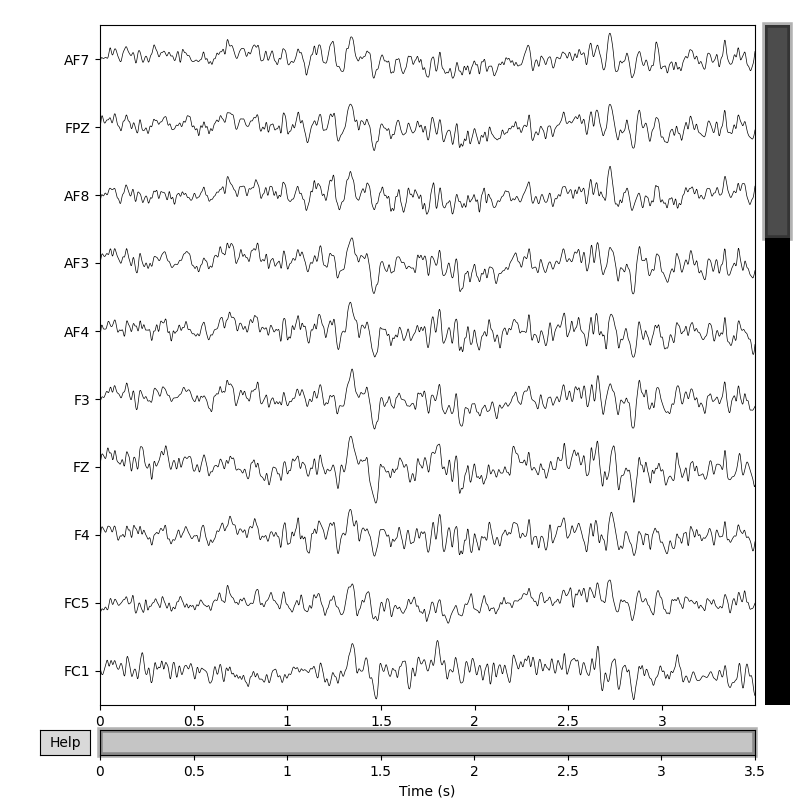

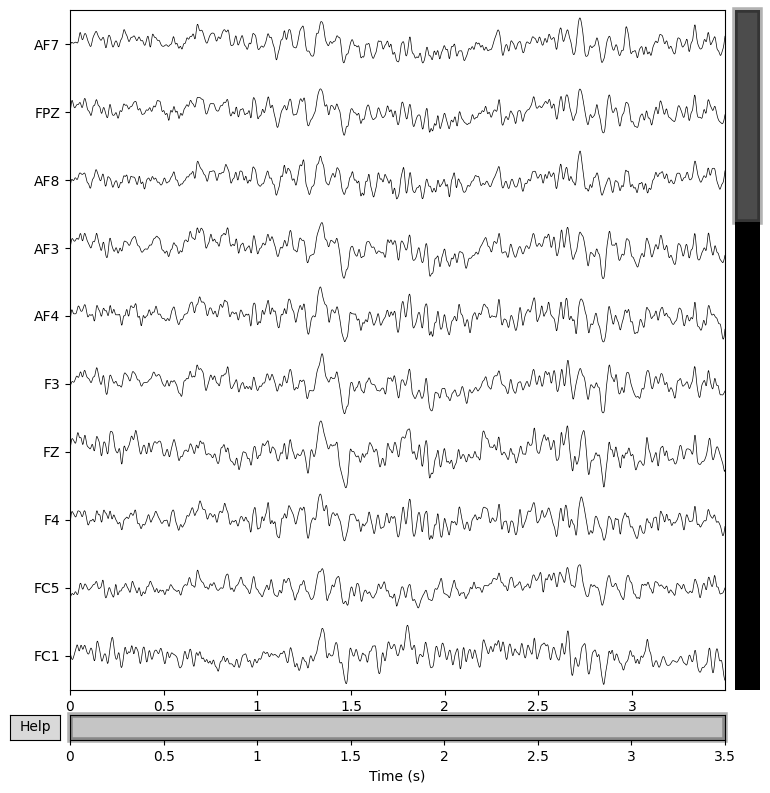

In [6]:
# Plot all channels for one trial index
plot_all_channels_by_trial(epochs, trial_idx=5)


### B) One channel across trials (stacked)
- Uses MNE plotting backend.
- Colors indicate condition-specific trial categories.
- Gray/no-auditory trials are removed by your current `utils.py` logic.


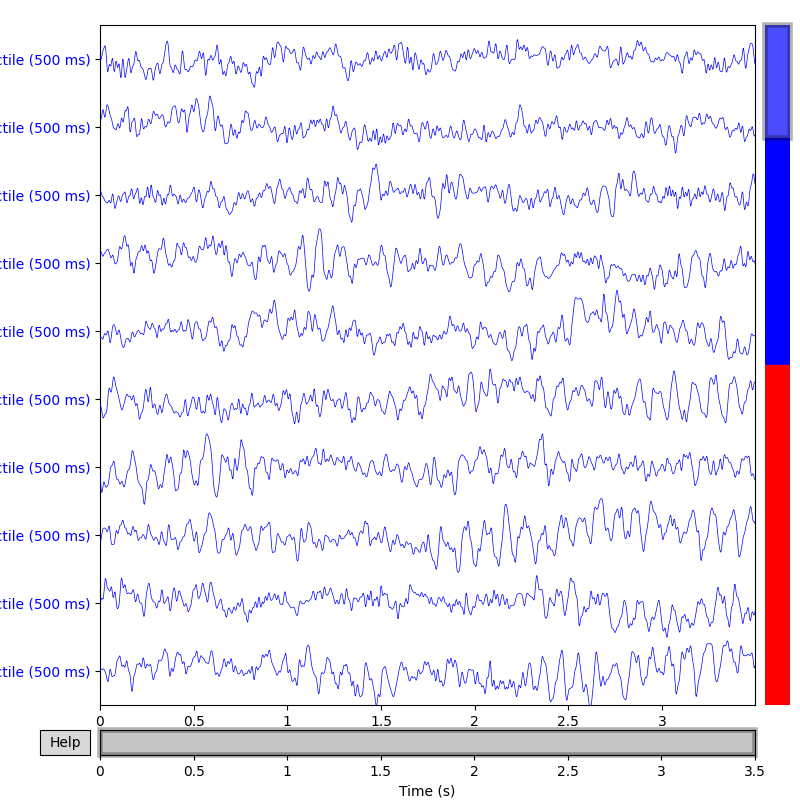

Color legend:
  Audio → Tactile (500 ms): blue
  Audio → Missing tactile: red


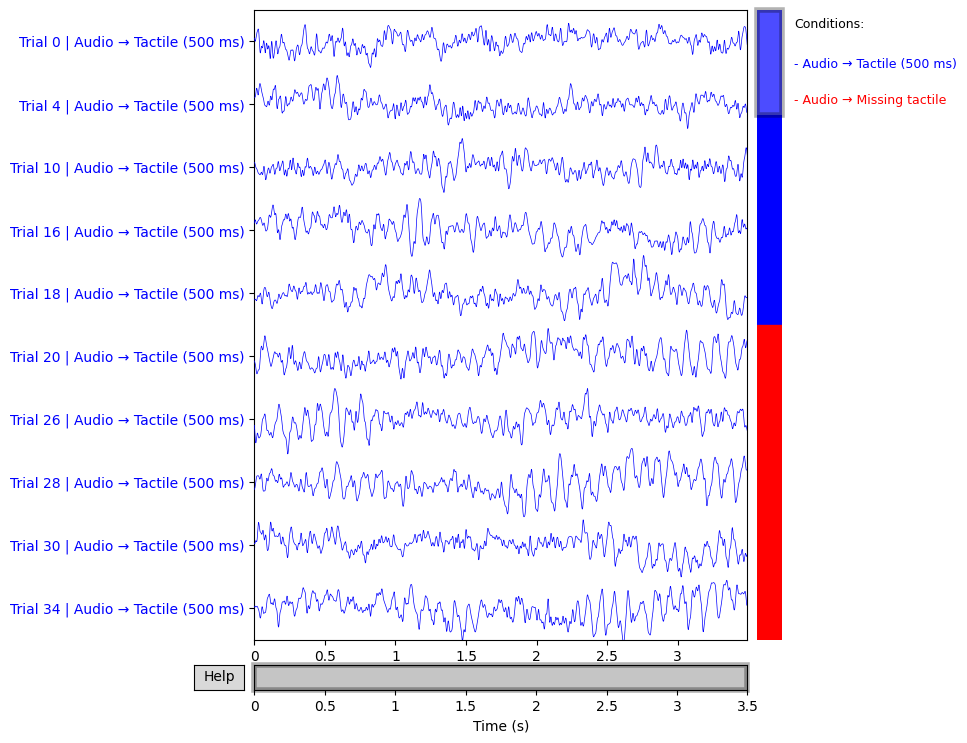

In [7]:
# Plot one channel across trials (interactive MNE browser)
plot_all_trials_by_channel(
    epochs=epochs,
    channel_name="Oz",
    window_size=10,
    condition="P3",  # optional if filename can be inferred
    block=False,
)


## 5) Common errors and fixes

### File not found
If you get `FileNotFoundError`, check:
- you are running from `Proyect_EEG/`,
- the file is in `dataset/`,
- condition and subject id match a real filename.

### Channel not found
If `Channel X not found`, print available channels:
- `print(epochs.ch_names)`

### Condition cannot be inferred
Pass it explicitly:
- `plot_all_trials_by_channel(..., condition="P3")`


In [8]:
# Optional: load and verify
epochs_demo = load_eeg_data("P3", 5)
print("Loaded successfully")


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Loaded successfully


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 6) Suggested workflow

1. Start with one subject and one condition.
2. Verify channels and trial count.
3. Use quick plots for quality checks.
4. Narrow channels/trials/frequency bands for your analysis.
5. Save results/figures in a separate folder (for example `results/`).
